# 01 什么是神经网络

这一节先不急着写复杂模型，而是把神经网络的核心直觉建立起来：神经网络本质上是一个可以通过数据自动调整参数的函数。

本节参考黑马程序员《神经网络与深度学习》课程的学习主线：先理解深度学习的发展与应用，再进入 PyTorch 框架、人工神经网络、反向传播、CNN 图像任务和 RNN 序列任务。


## 1. 学习目标

学完这一节，需要能回答下面几个问题：

1. 神经网络为什么可以看成一个函数？
2. 一个神经元到底做了什么计算？
3. 权重、偏置、激活函数分别有什么作用？
4. 训练神经网络时，损失函数、反向传播、优化器分别负责什么？
5. 为什么后面要继续学习 MLP、BP、CNN、RNN？


## 2. 神经网络是一类可训练函数

普通函数通常由人手写规则，例如：

$$
y = 2x + 1
$$

神经网络也是函数，只不过函数里的参数不是手工指定，而是从数据中学习出来。可以把一个神经网络记作：

$$
\hat{y} = f_{\theta}(x)
$$

其中：

- $x$ 表示输入数据，比如图片、文本、表格特征。
- $\hat{y}$ 表示模型预测结果。
- $f_{\theta}$ 表示带参数的函数。
- $\theta$ 表示模型中所有可学习参数，主要包括权重和偏置。

训练神经网络，就是不断调整 $\theta$，让 $\hat{y}$ 越来越接近真实标签 $y$。

注意：构建神经网络就是在构建神经元。


## 3. 一个神经元在计算什么

神经元可以先理解成三个动作：加权、求和、激活。

如果输入是一个向量：

$$
\mathbf{x} = [x_1, x_2, \dots, x_n]
$$

权重是：

$$
\mathbf{w} = [w_1, w_2, \dots, w_n]
$$

偏置是：

$$
b
$$

那么神经元先计算线性部分：

$$
z = \mathbf{w}^{T}\mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b
$$

然后通过激活函数得到输出：

$$
a = \sigma(z)
$$

其中 $\sigma$ 表示激活函数，$a$ 表示神经元的输出。


### 神经元结构图

下面这张图把一个神经元拆成输入、权重、偏置、求和、激活和输出几个部分。重点看清楚数据流向：

$$
\mathbf{x} \rightarrow z = \sum_{i=1}^{n} w_i x_i + b \rightarrow a = \sigma(z)
$$


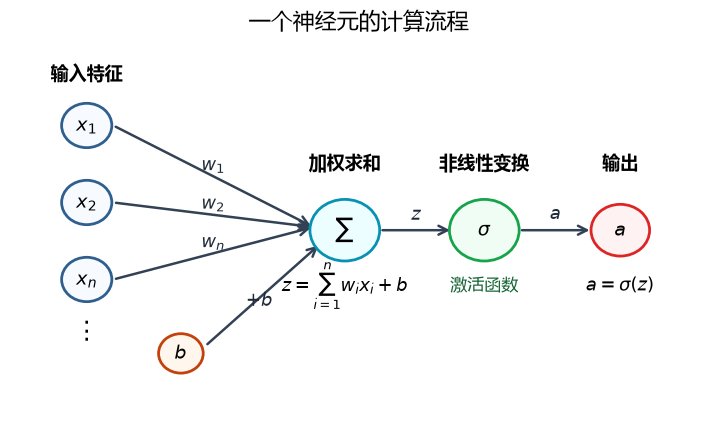

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

def draw_node(x, y, text, radius=0.36, facecolor='#F7FBFF', edgecolor='#2F5F8F'):
    node = Circle((x, y), radius, facecolor=facecolor, edgecolor=edgecolor, linewidth=2)
    ax.add_patch(node)
    ax.text(x, y, text, ha='center', va='center', fontsize=14)

def draw_arrow(start, end, label=None, label_offset=(0, 0)):
    arrow = FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=16, linewidth=1.8, color='#334155')
    ax.add_patch(arrow)
    if label:
        lx = (start[0] + end[0]) / 2 + label_offset[0]
        ly = (start[1] + end[1]) / 2 + label_offset[1]
        ax.text(lx, ly, label, ha='center', va='center', fontsize=13, color='#1F2937')

inputs = [(1.1, 4.7, r'$x_1$'), (1.1, 3.45, r'$x_2$'), (1.1, 2.2, r'$x_n$')]
weights = [r'$w_1$', r'$w_2$', r'$w_n$']

for (x_pos, y_pos, label), weight in zip(inputs, weights):
    draw_node(x_pos, y_pos, label)
    draw_arrow((x_pos + 0.38, y_pos), (4.35, 3.05), weight, label_offset=(0, 0.18))

ax.text(1.1, 1.35, r'$\vdots$', ha='center', va='center', fontsize=18)
draw_node(2.45, 1.0, r'$b$', radius=0.32, facecolor='#FFF7ED', edgecolor='#C2410C')
draw_arrow((2.8, 1.12), (4.45, 2.78), r'$+b$', label_offset=(-0.05, -0.1))

draw_node(4.8, 3.0, r'$\sum$', radius=0.5, facecolor='#ECFEFF', edgecolor='#0891B2')
ax.text(4.8, 2.1, r'$z=\sum_{i=1}^{n}w_i x_i+b$', ha='center', va='center', fontsize=13)

draw_arrow((5.3, 3.0), (6.35, 3.0), r'$z$', label_offset=(0, 0.25))
draw_node(6.8, 3.0, r'$\sigma$', radius=0.5, facecolor='#F0FDF4', edgecolor='#16A34A')
ax.text(6.8, 2.1, '激活函数', ha='center', va='center', fontsize=12, color='#166534')

draw_arrow((7.3, 3.0), (8.35, 3.0), r'$a$', label_offset=(0, 0.25))
draw_node(8.75, 3.0, r'$a$', radius=0.42, facecolor='#FEF2F2', edgecolor='#DC2626')
ax.text(8.75, 2.1, r'$a=\sigma(z)$', ha='center', va='center', fontsize=13)

ax.text(1.1, 5.45, '输入特征', ha='center', fontsize=13, weight='bold')
ax.text(4.8, 4.0, '加权求和', ha='center', fontsize=13, weight='bold')
ax.text(6.8, 4.0, '非线性变换', ha='center', fontsize=13, weight='bold')
ax.text(8.75, 4.0, '输出', ha='center', fontsize=13, weight='bold')

plt.title('一个神经元的计算流程', fontsize=16, pad=12)
plt.show()


## 4. 权重、偏置、激活函数的直觉

- 权重 $w_i$：决定第 $i$ 个输入特征有多重要。
- 偏置 $b$：让模型的判断边界可以平移，不必强行经过原点。
- 激活函数 $\sigma$：给模型加入非线性能力。

如果没有激活函数，多层线性变换叠在一起，本质上仍然只是一个线性变换。比如：

$$
\mathbf{y} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2
$$

展开后仍然可以写成：

$$
\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}
$$

所以，激活函数是神经网络能够拟合复杂关系的关键之一。


## 5. 常见激活函数

激活函数的作用，是把线性计算结果 $z$ 转换成新的输出 $a$：

$$
a = \phi(z)
$$

如果没有激活函数，多层神经网络无论堆多少层，本质上仍然只是一个线性模型；加入激活函数后，网络才有能力表达非线性关系。

这一节先重点掌握四个函数：Sigmoid、Tanh、ReLU、Softmax。

如果想看公式的完整来龙去脉，可以按下面四份推导笔记学习：

1. [Sigmoid 函数公式推导](01-01_Sigmoid函数公式推导.ipynb)
2. [Tanh 函数公式推导](01-02_Tanh函数公式推导.ipynb)
3. [ReLU 函数公式推导](01-03_ReLU函数公式推导.ipynb)
4. [Softmax 函数公式推导](01-04_Softmax函数公式推导.ipynb)
5. [参数初始化](01-05_参数初始化.ipynb)

### 5.1 Sigmoid 函数

Sigmoid 会把任意实数压缩到 $(0, 1)$ 区间：

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

它的输出可以被理解成概率，所以常用于二分类任务的输出层：

$$
\hat{y} = \sigma(z)
$$

当 $\hat{y} \ge 0.5$ 时，可以预测为类别 $1$；当 $\hat{y} < 0.5$ 时，可以预测为类别 $0$。

Sigmoid 的导数是：

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$

这个导数形式很漂亮，但也带来一个问题：当 $z$ 很大或很小时，$\sigma(z)$ 会接近 $1$ 或 $0$，此时导数会接近 $0$，梯度传递会变弱。

Sigmoid 的特点：

- 输出范围是 $(0, 1)$。
- 适合二分类输出层。
- 不太适合作为深层网络隐藏层的默认激活函数。
- 容易出现梯度饱和问题。

### 5.2 Tanh 函数

Tanh 会把任意实数压缩到 $(-1, 1)$ 区间：

$$
\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}
$$

Tanh 和 Sigmoid 的形状很像，但 Tanh 的输出以 $0$ 为中心。也就是说，当输入 $z=0$ 时：

$$
\tanh(0)=0
$$

Tanh 的导数是：

$$
\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)
$$

因为输出有正有负，所以在隐藏层中，Tanh 通常比 Sigmoid 更容易训练一些。不过当 $z$ 的绝对值很大时，它同样会进入饱和区，导致梯度变小。

Tanh 的特点：

- 输出范围是 $(-1, 1)$。
- 输出以 $0$ 为中心。
- 曾经常用于隐藏层，尤其是早期 RNN。
- 仍然可能出现梯度饱和问题。

### 5.3 ReLU 函数

ReLU 是深度学习中最常见的隐藏层激活函数之一：

$$
\operatorname{ReLU}(z) = \max(0, z)
$$

也可以写成分段形式：

$$
\operatorname{ReLU}(z)=
\begin{cases}
z, & z > 0 \\
0, & z \le 0
\end{cases}
$$

ReLU 的导数可以理解为：

$$
\operatorname{ReLU}'(z)=
\begin{cases}
1, & z > 0 \\
0, & z < 0
\end{cases}
$$

在 $z=0$ 处严格来说不可导，但在实际深度学习框架中通常会取一个约定值，不影响训练。

ReLU 的优势是计算简单，正半轴不会饱和，因此更适合训练深层网络。但它也有一个问题：如果某个神经元长期落在 $z \le 0$ 的区域，输出一直是 $0$，梯度也可能一直是 $0$，这个神经元就很难再被更新。这常被称为死亡 ReLU 问题。

ReLU 的特点：

- 输出范围是 $[0, +\infty)$。
- 常用于隐藏层。
- 计算简单，训练深层网络效果通常很好。
- 可能出现死亡 ReLU 问题。

### 5.4 Softmax 函数

Softmax 通常用于多分类任务的输出层。它不是处理单个数，而是处理一组类别分数。

假设模型对 $K$ 个类别输出原始分数：

$$
\mathbf{z} = [z_1, z_2, \dots, z_K]
$$

Softmax 会把第 $i$ 个类别的分数转换成概率：

$$
\operatorname{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

Softmax 输出满足两个性质：

$$
0 < \operatorname{softmax}(z_i) < 1
$$

$$
\sum_{i=1}^{K}\operatorname{softmax}(z_i)=1
$$

所以它可以被看成一个概率分布。比如三分类任务中，输出可能是：

$$
[0.05, 0.90, 0.05]
$$

这表示模型认为第 $2$ 类的概率最大。

Softmax 的特点：

- 用于多分类输出层。
- 输出是一组概率，所有概率之和为 $1$。
- 常和交叉熵损失一起使用。
- 在 PyTorch 中，多分类训练通常直接使用 `nn.CrossEntropyLoss()`，此时不需要手动先写 Softmax。

### 5.5 四个激活函数怎么选

| 任务位置 | 常用选择 | 原因 |
|---|---|---|
| 隐藏层 | ReLU | 训练快，适合深层网络 |
| 二分类输出层 | Sigmoid | 输出可以解释成类别 $1$ 的概率 |
| 多分类输出层 | Softmax | 输出多个类别的概率分布 |
| 特定隐藏层或序列模型 | Tanh | 输出以 $0$ 为中心，历史上常用于 RNN |

先记住一个实用规则：隐藏层优先想到 ReLU，二分类输出想到 Sigmoid，多分类输出想到 Softmax。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, sigmoid, label='Sigmoid')
axes[0].plot(z, tanh, label='Tanh')
axes[0].plot(z, relu, label='ReLU')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Sigmoid / Tanh / ReLU')
axes[0].set_xlabel('z')
axes[0].set_ylabel('activation(z)')
axes[0].legend()
axes[0].grid(alpha=0.3)

scores = np.array([1.2, 3.5, 0.8])
exp_scores = np.exp(scores - np.max(scores))
softmax = exp_scores / np.sum(exp_scores)

axes[1].bar(['class 1', 'class 2', 'class 3'], softmax, color=['#93C5FD', '#FCA5A5', '#86EFAC'])
axes[1].set_ylim(0, 1)
axes[1].set_title('Softmax Probabilities')
axes[1].set_ylabel('probability')
for i, p in enumerate(softmax):
    axes[1].text(i, p + 0.03, f'{p:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()


## 6. 从单个神经元到多层网络

多个神经元排在一起，就是一层网络。多层网络可以写成：

$$
\mathbf{h}^{(1)} = \sigma(\mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)})
$$

$$
\mathbf{h}^{(2)} = \sigma(\mathbf{W}^{(2)}\mathbf{h}^{(1)} + \mathbf{b}^{(2)})
$$

$$
\hat{\mathbf{y}} = g(\mathbf{W}^{(3)}\mathbf{h}^{(2)} + \mathbf{b}^{(3)})
$$

其中：

- $\mathbf{x}$ 是输入层。
- $\mathbf{h}^{(1)}$ 和 $\mathbf{h}^{(2)}$ 是隐藏层。
- $\hat{\mathbf{y}}$ 是输出层。
- $g$ 是输出层激活函数，具体选择取决于任务。

这种结构通常叫多层感知机，也就是 MLP。后面学习 BP 神经网络时，会重点研究它如何训练。


## 7. 训练神经网络的四个核心角色

神经网络训练可以先拆成四个角色：

1. 前向传播：用当前参数算出预测值 $\hat{y}$。
2. 损失函数：衡量预测值 $\hat{y}$ 和真实值 $y$ 的差距。
3. 反向传播：计算损失对每个参数的梯度。
4. 优化器：根据梯度更新参数。

以回归任务常见的均方误差为例：

$$
\mathcal{L}(\hat{y}, y) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

参数更新可以先理解成梯度下降：

$$
\theta \leftarrow \theta - \eta \frac{\partial \mathcal{L}}{\partial \theta}
$$

其中 $\eta$ 是学习率，$\frac{\partial \mathcal{L}}{\partial \theta}$ 是损失函数对参数 $\theta$ 的梯度。


## 8. 小实验：手算一个神经元

假设一个样本有两个特征：

$$
\mathbf{x} = [0.8, 0.4]
$$

神经元参数为：

$$
\mathbf{w} = [0.5, -0.3], \quad b = 0.1
$$

先计算：

$$
z = 0.5 \times 0.8 + (-0.3) \times 0.4 + 0.1
$$

再经过 Sigmoid：

$$
a = \frac{1}{1 + e^{-z}}
$$

下面用 NumPy 验证一下。


In [ ]:
x = np.array([0.8, 0.4])
w = np.array([0.5, -0.3])
b = 0.1

z = np.dot(w, x) + b
a = 1 / (1 + np.exp(-z))

print('z =', z)
print('a =', a)


## 9. 为什么需要多层网络

线性模型擅长处理线性可分问题，但很多真实任务并不是简单直线、平面或超平面能分开的。

例如异或问题的规则是：两个输入不同则输出 $1$，两个输入相同则输出 $0$。

$$
\begin{array}{c|c|c}
x_1 & x_2 & y \\
\hline
0 & 0 & 0 \\
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 0
\end{array}
$$

这个问题无法被一个简单线性分类器完美分开，但可以用带隐藏层的神经网络表达。


In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

def step(v):
    return (v > 0).astype(int)

# 隐藏层第一个神经元学习 OR，第二个神经元学习 NAND。
W1 = np.array([
    [1, 1],
    [-1, -1]
])
b1 = np.array([-0.5, 1.5])

# 输出层学习 AND。
W2 = np.array([1, 1])
b2 = -1.5

H = step(X @ W1.T + b1)
y_hat = step(H @ W2 + b2)

print('输入 X:')
print(X)
print('\n隐藏层 H:')
print(H)
print('\n预测 y_hat:', y_hat)
print('真实 y:   ', y)


## 10. 激活函数的选择

对于隐藏层：

1. ReLU 是默认选择，训练深层网络效果通常很好。
2. 如果效果不好，可以尝试 ReLU 的变体（Leaky ReLU、ELU、GELU 等）可以缓解死亡 ReLU 问题。
3. 少使用 Sigmoid函数，可以尝试 Tanh 函数，尤其是 RNN 里。

对于输出层：
1. 二分类任务：Sigmoid。
2. 多分类任务：Softmax。
3. 回归任务：线性激活函数（Identity）。




## 11. 本节总结

这一节先记住三句话：

1. 神经网络是带参数的函数，核心形式是 $\hat{y} = f_{\theta}(x)$。
2. 神经元的基本计算是 $a = \sigma(\mathbf{w}^{T}\mathbf{x} + b)$。
3. 训练的目标是最小化损失函数 $\mathcal{L}$，通过梯度下降更新参数 $\theta$。

下一节建议进入：感知机与多层感知机，重点理解为什么单层模型不够、隐藏层如何提升表达能力。
